In [11]:
import pandas as pd

df = pd.read_csv("../../data/online_shoppers_intention.csv", encoding = "utf-8")

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


# 데이터 전처리 ( 정규화는 제외 )


In [12]:
# boool 값들 int 변환
df['Revenue'] = df['Revenue'].astype(int) # 구매여부 1, 0
df['Weekend'] = df['Weekend'].astype(int) # 주말여부 1, 0

# Month 1 ~ 12 로 변환
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'June': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df['Month'] = df['Month'].map(month_map)

# Visitor type - 0, 1, 2 로 변환
visitor_map = {'Returning_Visitor': 0, 
               'New_Visitor': 1,
               'Other': 2} 
# 타입이 string > int 타입으로 변환되어야함
df['VisitorType'] = df['VisitorType'].map(visitor_map)
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,0,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,0,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,0,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,0,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,0,1,0


In [13]:
# 어떤걸 목표로 분석을 시작할까 

# 구매 확률 점수 예측?
 
# PageValue 예측? 

# 체류시간 예측? 

# 어떤 유입과 디바이스 조합이 이탈을 유발하는가?

# KNN 회귀를 활용한 구매 확률 예측
# y = Revenue(0/1)을 회귀로 풀면, 이웃 K명 중 구매한 사람의 비율 = 0~1 사이의 "구매 확률 점수"가 된다.

In [14]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. drop_cols로부터 feature_cols 생성
drop_cols = ['Revenue', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df['Revenue']  # 이미 0/1 int

# 2. 훈련 80 / 테스트 20 (Revenue 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. 정규화 (학습 데이터 기준으로 fit 누수 방지)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. KNN 회귀 모델 학습
#    k는 임의로 7로 설정 (홀수 → 동률 회피, 너무 작으면 노이즈 민감, 너무 크면 둔감)
K = 7
knn = KNeighborsRegressor(n_neighbors=K)
knn.fit(X_train_scaled, y_train)

# 5. 테스트 데이터로 구매 확률 예측 (이웃 K명 중 구매자 비율 = 0~1)
y_proba = knn.predict(X_test_scaled)

# print(y_proba[:10])
print(f"\nK = {K}")
print(f"예측 확률 샘플 10개: {y_proba[:10]}")
print(f"예측 확률 범위    : {y_proba.min():.3f} ~ {y_proba.max():.3f}")
print(f"평균 예측 확률    : {y_proba.mean():.3f}")
print(f"실제 구매 비율    : {y_test.mean():.3f}")


K = 7
예측 확률 샘플 10개: [0.         0.         0.85714286 0.         0.         0.
 0.         0.28571429 0.         0.28571429]
예측 확률 범위    : 0.000 ~ 1.000
평균 예측 확률    : 0.142
실제 구매 비율    : 0.155


## 수동 K 스윕 — K마다 직접 학습해서 결과 비교

K=7은 임의값. **K를 직접 바꿔가며 학습**시키고 테스트셋 결과를 한 표로 모은다.

### K 후보 선정 — 왜 로그 간격인가
KNN에서 이웃 1명이 차지하는 가중치는 **1/K**. 즉 K가 변할 때 예측이 얼마나 바뀌는지는 **1/K가 얼마나 바뀌는지에 비례**한다.

| 구간 | 1/K 변화 | 비고 |
|---|---:|---|
| K=1 → 3 | 1.00 → 0.33 (−67%) | 큰 변화 — 촘촘히 봐야 함 |
| K=11 → 13 | 0.091 → 0.077 (−15%) | 차이 거의 없음 |
| K=51 → 53 | 0.020 → 0.019 (−4%) | 노이즈 수준 |

→ **작은 K는 촘촘히, 큰 K는 로그 간격**으로 12점 샘플링:
```
[1, 3, 5, 7, 11, 15, 21, 31, 51, 75, 101, 151]
```
$\sqrt{N_{train}} \approx \sqrt{9864} \approx 99$ 라는 경험칙도 함께 만족 (K=100 부근까지 커버 → plateau 확인 가능).

### 표에서 보는 것
- **mean_proba**: K가 클수록 평균이 실제 구매율(0.155)에 수렴 (이웃을 많이 볼수록 보수적)
- **pct_zero_proba**: K가 작을수록 "확률 0"으로 찍히는 세션 비율이 큼 — **양극화 지표**
- **test_AUC**: K 변화에 따른 순위 분리 성능 — 너무 작으면 노이즈, 너무 크면 둔감
- **test_Brier**: 확률값의 정밀도 (↓ 좋음)

In [15]:
from sklearn.metrics import roc_auc_score, brier_score_loss

# K 후보 — 로그 간격 샘플링 (작은 K는 촘촘, 큰 K는 띄엄띄엄)
# 근거: 이웃 가중치 1/K가 K에 반비례 → K=11→13(−15%)보다 K=1→3(−67%)이 훨씬 큰 변화
# 상한 151: sqrt(N_train≈9864)≈99 경험칙 + plateau 확인 여유
K_SWEEP = [1, 3, 5, 7, 11, 15, 21, 31, 51, 75, 101, 151]

rows = []
for k in K_SWEEP:
    model = KNeighborsRegressor(n_neighbors=k) # 기본값: weights='uniform', p=2 (Euclidean)
    model.fit(X_train_scaled, y_train)
    p_hat = model.predict(X_test_scaled)

    rows.append({
        'K': k,
        'mean_proba': p_hat.mean(), # 평균 예측 확률
        'min_proba': p_hat.min(),
        'max_proba': p_hat.max(),
        'pct_zero_proba': (p_hat == 0).mean(), # 양극화 지표 (K 작을수록 ↑)
        'pct_one_proba': (p_hat == 1).mean(),
        'test_AUC': roc_auc_score(y_test, p_hat),
        'test_Brier': brier_score_loss(y_test, p_hat), # ↓ 좋음
    })

sweep_df = pd.DataFrame(rows).set_index('K')

print(f"[참고] 실제 구매 비율 (y_test): {y_test.mean():.4f}\n")
print("▼ K별 수동 학습 결과 (test셋 단일 분할)")
print(sweep_df.round(4).to_string())

best_k_manual = sweep_df['test_AUC'].idxmax()
print(f"\n→ 테스트 AUC 최고: K = {best_k_manual}  (AUC = {sweep_df.loc[best_k_manual, 'test_AUC']:.4f})")
print("   ※ 단, test셋 단일 분할이라 운에 흔들림. 아래에서 5-fold CV로 한 번 더 검증한다.")

[참고] 실제 구매 비율 (y_test): 0.1549

▼ K별 수동 학습 결과 (test셋 단일 분할)
     mean_proba  min_proba  max_proba  pct_zero_proba  pct_one_proba  test_AUC  test_Brier
K                                                                                         
1        0.1529        0.0     1.0000          0.8471         0.1529    0.7038      0.1537
3        0.1433        0.0     1.0000          0.7291         0.0454    0.7801      0.1070
5        0.1426        0.0     1.0000          0.6573         0.0284    0.8219      0.0943
7        0.1417        0.0     1.0000          0.5949         0.0207    0.8393      0.0900
11       0.1418        0.0     1.0000          0.5166         0.0138    0.8522      0.0892
15       0.1412        0.0     1.0000          0.4558         0.0069    0.8602      0.0873
21       0.1383        0.0     1.0000          0.3982         0.0041    0.8691      0.0878
31       0.1372        0.0     1.0000          0.3317         0.0004    0.8721      0.0884
51       0.1345        0.0    

## 5-fold 교차검증 — 수동 for문으로 직접 구현

위 표는 test셋 단일 분할 결과라 운에 의해 K 순위가 흔들릴 수 있음.  
**train셋을 5등분해서 5번 학습·검증을 반복**하고 평균 AUC로 K를 고른다 — 이게 교차검증.

KNN의 세 하이퍼파라미터를 모두 직접 비교:
- `n_neighbors` (K) — 이웃 수가 늘면 결정경계가 매끈해짐 (bias↑ / variance↓)
- `weights` — `uniform`(이웃 동일가중) vs `distance`(가까운 이웃에 큰 가중)
- `p` — `1`(Manhattan, 각 축 절댓값 합) vs `2`(Euclidean, 직선거리)

`StratifiedKFold`로 fold마다 양성 15.5% 비율 유지. 라이브러리 자동화(`GridSearchCV`) 대신 **3중 for문을 직접 써서 알고리즘 흐름을 노출**한다 — 보고 목적은 "KNN을 어떻게 적용했나"이지 sklearn 도구 소개가 아님.

In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

# 후보 — K_SWEEP은 위 셀에서 정의됨 (로그 간격 12점: [1, 3, 5, 7, 11, 15, 21, 31, 51, 75, 101, 151])
WEIGHTS = ['uniform', 'distance']
P_VALS = [1, 2] # 1=Manhattan, 2=Euclidean

# StratifiedKFold: fold마다 양성 비율(15.5%) 유지 — 불균형 타겟 필수
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3중 for문 — K × weights × p 모든 조합을 5-fold로 직접 평가
cv_rows = []
for k in K_SWEEP:
    for w in WEIGHTS:
        for p in P_VALS:
            fold_aucs = []
            for tr_idx, va_idx in cv.split(X_train_scaled, y_train):
                X_tr, X_va = X_train_scaled[tr_idx], X_train_scaled[va_idx]
                y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

                m = KNeighborsRegressor(n_neighbors=k, weights=w, p=p)
                m.fit(X_tr, y_tr)
                fold_aucs.append(roc_auc_score(y_va, m.predict(X_va)))

            cv_rows.append({
                'K': k,
                'weights': w,
                'p': p,
                'cv_AUC_mean': np.mean(fold_aucs),
                'cv_AUC_std': np.std(fold_aucs),
            })

cv_df = pd.DataFrame(cv_rows)

# 최적 조합 선정
best = cv_df.sort_values('cv_AUC_mean', ascending=False).iloc[0]
best_k, best_w, best_p = int(best['K']), best['weights'], int(best['p'])

print(f"탐색 조합 수 : {len(K_SWEEP)} × {len(WEIGHTS)} × {len(P_VALS)} = {len(cv_rows)}")
print(f"각 조합 학습 횟수 : 5 (fold) → 총 {len(cv_rows) * 5}번 학습\n")

print("▼ CV AUC 상위 5개 조합")
print(cv_df.sort_values('cv_AUC_mean', ascending=False)
      .head(5).to_string(index=False))

print(f"\n→ 선정: K={best_k}, weights='{best_w}', p={best_p}  "
      f"(CV AUC = {best['cv_AUC_mean']:.4f} ± {best['cv_AUC_std']:.4f})")

# 최적 조합으로 train 전체 재학습 → test 예측 (이후 평가 셀들이 이 knn / y_proba 사용)
knn = KNeighborsRegressor(n_neighbors=best_k, weights=best_w, p=best_p)
knn.fit(X_train_scaled, y_train)
y_proba = knn.predict(X_test_scaled)
K = best_k

print(f"\n[최종 모델] test 예측 확률 범위 : {y_proba.min():.3f} ~ {y_proba.max():.3f}")
print(f"[최종 모델] test 평균 예측 확률 : {y_proba.mean():.3f}")
print(f"[참고]      실제 구매 비율      : {y_test.mean():.3f}")

탐색 조합 수 : 12 × 2 × 2 = 48
각 조합 학습 횟수 : 5 (fold) → 총 240번 학습

▼ CV AUC 상위 5개 조합
  K  weights  p  cv_AUC_mean  cv_AUC_std
 75 distance  1     0.897489    0.006842
 51 distance  1     0.897397    0.007463
101 distance  1     0.896158    0.006262
 31 distance  1     0.895092    0.006585
151 distance  1     0.894949    0.006048

→ 선정: K=75, weights='distance', p=1  (CV AUC = 0.8975 ± 0.0068)

[최종 모델] test 예측 확률 범위 : 0.000 ~ 0.979
[최종 모델] test 평균 예측 확률 : 0.124
[참고]      실제 구매 비율      : 0.155


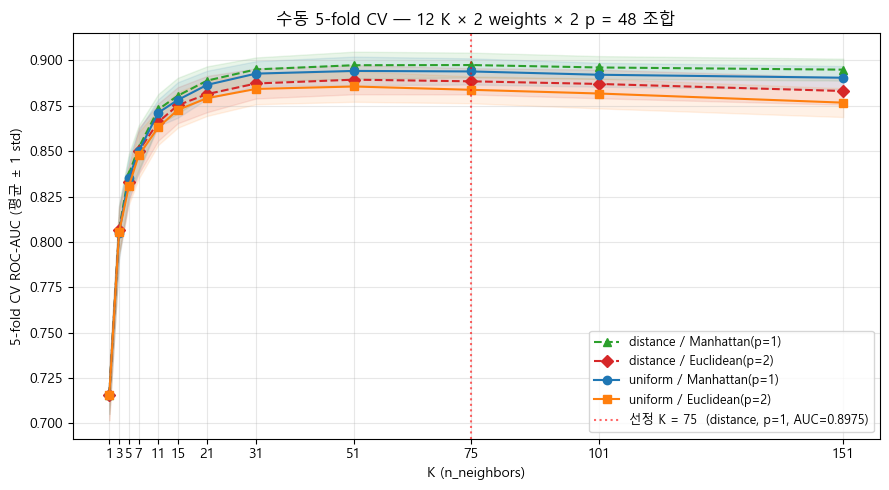

In [17]:
import matplotlib.pyplot as plt
import platform

# 한글 폰트
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# (weights, p) 4조합별로 K vs CV AUC 라인 → 한 차트에 한꺼번에
fig, ax = plt.subplots(figsize=(9, 5))
style_map = {
    ('uniform', 1): {'marker': 'o', 'linestyle': '-', 'color': '#1f77b4'},
    ('uniform', 2): {'marker': 's', 'linestyle': '-', 'color': '#ff7f0e'},
    ('distance', 1): {'marker': '^', 'linestyle': '--', 'color': '#2ca02c'},
    ('distance', 2): {'marker': 'D', 'linestyle': '--', 'color': '#d62728'},
}

for (w, p), sub in cv_df.groupby(['weights', 'p']):
    sub = sub.sort_values('K')
    metric = 'Manhattan(p=1)' if p == 1 else 'Euclidean(p=2)'
    # 평균선 + ±1 std 음영 (CV의 안정성도 시각화)
    ax.plot(sub['K'], sub['cv_AUC_mean'],
            label=f'{w} / {metric}', **style_map[(w, p)])
    ax.fill_between(sub['K'],
                    sub['cv_AUC_mean'] - sub['cv_AUC_std'],
                    sub['cv_AUC_mean'] + sub['cv_AUC_std'],
                    color=style_map[(w, p)]['color'], alpha=0.10)

# 최적 K 강조
ax.axvline(best_k, color='red', linestyle=':', alpha=0.6,
           label=f"선정 K = {best_k}  ({best_w}, p={best_p}, AUC={best['cv_AUC_mean']:.4f})")

ax.set_xlabel('K (n_neighbors)')
ax.set_ylabel('5-fold CV ROC-AUC (평균 ± 1 std)')
ax.set_title(f'수동 5-fold CV — {len(K_SWEEP)} K × 2 weights × 2 p = {len(cv_rows)} 조합')
ax.set_xticks(K_SWEEP)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 평가 — 표준 이진 분류 지표 + 확률 품질

양성 15.5% 불균형 → 정확도 단독 무의미. 5개 지표로 분리해서 봄.

- **ROC-AUC** : 확률 순위가 양/음을 분리하는 정도
- **PR-AUC (Average Precision)** : 양성 비율 낮을 때 ROC-AUC 낙관 편향 보정
- **F1 / Precision / Recall** (임계 0.5) : 실무 보고서 표준 묶음
- **Brier** : 확률 보정 품질 (↓ 좋음) — KNN 회귀의 강점 정량화

회귀 지표(R²·MAE·RMSE)는 KNN을 회귀로 푼 수업 프레임상 산출 가능하지만 이진 분류 보고에 어색해서 제외.

In [18]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    f1_score, precision_score, recall_score
)

# 임계값 0.5 기준 이진 예측 (F1·Precision·Recall 계산용)
y_pred = (y_proba >= 0.5).astype(int)

auc   = roc_auc_score(y_test, y_proba)
ap    = average_precision_score(y_test, y_proba)
brier = brier_score_loss(y_test, y_proba)
prec  = precision_score(y_test, y_pred, zero_division=0)
rec   = recall_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred)

baseline_ap    = y_test.mean()
baseline_brier = y_test.mean() * (1 - y_test.mean())

print("▼ 확률 품질 지표")
print(f"  ROC-AUC   : {auc:.4f}")
print(f"  PR-AUC    : {ap:.4f}   (베이스라인 = {baseline_ap:.4f})")
print(f"  Brier     : {brier:.4f}   (베이스라인 = {baseline_brier:.4f})")

print("\n▼ 임계값 0.5 기준 분류 지표")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1        : {f1:.4f}")

▼ 확률 품질 지표
  ROC-AUC   : 0.8830
  PR-AUC    : 0.6192   (베이스라인 = 0.1549)
  Brier     : 0.0892   (베이스라인 = 0.1309)

▼ 임계값 0.5 기준 분류 지표
  Precision : 0.8047
  Recall    : 0.2696
  F1        : 0.4039


In [19]:
# 예측 확률 상위 15명 (가장 구매 가능성이 높다고 본 세션)
result = pd.DataFrame({
    'predicted_proba': y_proba,
    'actual_revenue':  y_test.values
}).reset_index(drop=True)

print("▼ 예측 확률 상위 15 (실제 구매여부와 비교)")
print(result.sort_values('predicted_proba', ascending=False).head(15))

print("\n▼ 예측 확률 구간별 실제 구매율 (calibration)")
result['bin'] = pd.cut(result['predicted_proba'],
                       bins=[-0.01, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
print(result.groupby('bin', observed=True)['actual_revenue']
            .agg(['count', 'mean'])
            .rename(columns={'mean': 'actual_buy_rate'}))

▼ 예측 확률 상위 15 (실제 구매여부와 비교)
      predicted_proba  actual_revenue
1124         0.978629               0
2060         0.968580               1
1592         0.967839               1
119          0.961479               1
1406         0.959142               1
2327         0.953570               1
1907         0.950809               1
1427         0.937557               1
2            0.937361               1
2255         0.921343               1
2309         0.919748               0
1205         0.918004               1
2458         0.916332               1
2253         0.913991               1
2338         0.910174               1

▼ 예측 확률 구간별 실제 구매율 (calibration)
              count  actual_buy_rate
bin                                 
(-0.01, 0.0]    603         0.003317
(0.0, 0.2]     1362         0.084435
(0.2, 0.4]      309         0.401294
(0.4, 0.6]       95         0.621053
(0.6, 0.8]       60         0.850000
(0.8, 1.0]       37         0.837838


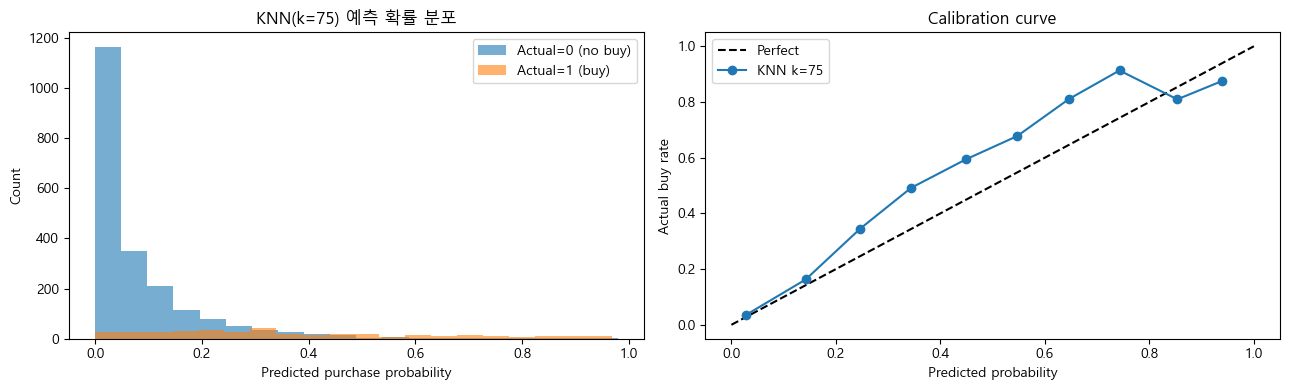

In [20]:
import matplotlib.pyplot as plt
import platform

# 한글 폰트 설정 (Windows / Mac 자동 선택)
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'  # Linux
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (1) 실제 클래스별 예측 확률 분포
axes[0].hist(y_proba[y_test == 0], bins=20, alpha=0.6, label='Actual=0 (no buy)')
axes[0].hist(y_proba[y_test == 1], bins=20, alpha=0.6, label='Actual=1 (buy)')
axes[0].set_xlabel('Predicted purchase probability')
axes[0].set_ylabel('Count')
axes[0].set_title(f'KNN(k={K}) 예측 확률 분포')
axes[0].legend()

# (2) Calibration curve — 예측 확률 vs 실제 구매율
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='uniform')
axes[1].plot([0, 1], [0, 1], 'k--', label='Perfect')
axes[1].plot(prob_pred, prob_true, marker='o', label=f'KNN k={K}')
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Actual buy rate')
axes[1].set_title('Calibration curve')
axes[1].legend()

plt.tight_layout()
plt.show()

# 7. 개선 검증 — KNN.md 부록 C에서 짚은 한계 항목 실험

KNN.md 부록 C의 개선 방향 중 **1·3·5번**을 실제로 돌려서 원본 모델과 비교한다.
- **7-1. PageValues 제외** — 데이터 누수 의심 검증 (부록 B-6)
- **7-2. VisitorType One-Hot** — 명목형 인코딩 일관성 회복 (전처리 한계)
- **7-3. 로그 변환** — 우편향 분포 변수 outlier 영향 완화

세 실험 모두 **최종 선정된 KNN 설정**(K=75, weights='distance', p=1)으로 학습 → ROC-AUC 변동을 본다.
원본 기준선: ROC-AUC = 0.8830, PR-AUC = 0.6192, Brier = 0.0892


## 7-1. PageValues 제외 검증 — "AUC 0.883이 누수 덕분이 아닌가?"

`PageValues`는 해당 세션의 페이지가 만들어낸 평균 거래 가치 → **구매 발생 이후에 산출되는 사후 정보일 가능성**.
원본 모델에서 이 변수 **하나만 제거**하고 같은 KNN으로 재학습 → AUC 변동을 본다.

| AUC 변동 | 해석 |
|---|---|
| 0.75 미만으로 떨어짐 | PageValues 의존도 큼. **누수 의심 사실**. 실배포 부적합 |
| 0.75 ~ 0.82 | PageValues 영향 분명. 도메인 검증 필요 |
| 0.82 이상 유지 | 다른 변수가 신호 충분히 담음. **안전** |


In [21]:
# PageValues 제외 → 동일 KNN 설정으로 재학습
feature_cols_no_pv = [c for c in feature_cols if c != 'PageValues']
X_no_pv = df[feature_cols_no_pv]

X_tr_npv, X_te_npv, y_tr_npv, y_te_npv = train_test_split(
    X_no_pv, y, test_size=0.2, random_state=42, stratify=y
)
sc_npv = StandardScaler()
X_tr_npv_s = sc_npv.fit_transform(X_tr_npv)
X_te_npv_s = sc_npv.transform(X_te_npv)

knn_npv = KNeighborsRegressor(n_neighbors=best_k, weights=best_w, p=best_p)
knn_npv.fit(X_tr_npv_s, y_tr_npv)
y_proba_npv = knn_npv.predict(X_te_npv_s)

auc_npv   = roc_auc_score(y_te_npv, y_proba_npv)
ap_npv    = average_precision_score(y_te_npv, y_proba_npv)
brier_npv = brier_score_loss(y_te_npv, y_proba_npv)
y_pred_npv = (y_proba_npv >= 0.5).astype(int)
precision_npv = precision_score(y_te_npv, y_pred_npv, zero_division=0)
recall_npv = recall_score(y_te_npv, y_pred_npv)
f1_npv = f1_score(y_te_npv, y_pred_npv)
top15_npv_actual_buyers = int(y_te_npv.iloc[np.argsort(-y_proba_npv)[:15]].sum())

print(f"▼ PageValues 제외 모델 (K={best_k}, weights='{best_w}', p={best_p})")
print(f"  피처 수    : {len(feature_cols_no_pv)} (원본 {len(feature_cols)}개 → -1)")
print(f"  ROC-AUC   : {auc_npv:.4f}   (원본 {auc:.4f}, Δ {auc_npv - auc:+.4f})")
print(f"  PR-AUC    : {ap_npv:.4f}   (원본 {ap:.4f}, Δ {ap_npv - ap:+.4f})")
print(f"  Brier     : {brier_npv:.4f}   (원본 {brier:.4f}, Δ {brier_npv - brier:+.4f})")
print(f"  Precision : {precision_npv:.4f}   (임계값 0.5)")
print(f"  Recall    : {recall_npv:.4f}   (임계값 0.5)")
print(f"  F1        : {f1_npv:.4f}   (임계값 0.5)")
print(f"  상위 15명 실제 구매자 수: {top15_npv_actual_buyers}/15")

if auc_npv < 0.75:
    verdict = "PageValues 의존도 큼. 데이터 누수 의심 — 실배포 시 재검토 필요."
elif auc_npv < 0.82:
    verdict = "PageValues 영향 분명. 도메인 정의 확인 필요."
else:
    verdict = "PageValues 없이도 AUC 유지. 다른 변수가 신호 충분히 담음 — 안전."
print(f"\n→ 판정: {verdict}")
print(f"→ 실전 기준 인사이트: PageValues 없이도 AUC {auc_npv:.4f}로 랜덤보다는 높지만, 원본의 강한 성능은 PageValues 의존도가 컸다.")


▼ PageValues 제외 모델 (K=75, weights='distance', p=1)
  피처 수    : 12 (원본 13개 → -1)
  ROC-AUC   : 0.7352   (원본 0.8830, Δ -0.1478)
  PR-AUC    : 0.3148   (원본 0.6192, Δ -0.3043)
  Brier     : 0.1193   (원본 0.0892, Δ +0.0301)
  Precision : 0.2500   (임계값 0.5)
  Recall    : 0.0052   (임계값 0.5)
  F1        : 0.0103   (임계값 0.5)
  상위 15명 실제 구매자 수: 7/15

→ 판정: PageValues 의존도 큼. 데이터 누수 의심 — 실배포 시 재검토 필요.
→ 실전 기준 인사이트: PageValues 없이도 AUC 0.7352로 랜덤보다는 높지만, 원본의 강한 성능은 PageValues 의존도가 컸다.


## 7-2. VisitorType One-Hot — 명목형 인코딩 일관성 회복

원본은 Returning=0, New=1, Other=2 **정수 매핑** → 거리 계산에서 "Other가 New보다 2배 멀다"는 의미 발생 (명목형인데 순서가 생김).
One-Hot으로 풀면 세 카테고리가 서로 직교 (서로의 거리 √2로 동일) → 명목형 본래 의미 회복.


In [22]:
# VisitorType 정수 → One-Hot 복원
visitor_inverse = {0: 'Returning', 1: 'New', 2: 'Other'}
df_oh = df.copy()
df_oh['VisitorType_label'] = df_oh['VisitorType'].map(visitor_inverse)
visitor_dummies = pd.get_dummies(df_oh['VisitorType_label'], prefix='Visitor').astype(int)

# feature_cols에서 VisitorType 빼고 dummy 3개 추가
base_cols = [c for c in feature_cols if c != 'VisitorType']
X_oh = pd.concat([df_oh[base_cols], visitor_dummies], axis=1)
feature_cols_oh = list(X_oh.columns)

X_tr_oh, X_te_oh, y_tr_oh, y_te_oh = train_test_split(
    X_oh, y, test_size=0.2, random_state=42, stratify=y
)
sc_oh = StandardScaler()
X_tr_oh_s = sc_oh.fit_transform(X_tr_oh)
X_te_oh_s = sc_oh.transform(X_te_oh)

knn_oh = KNeighborsRegressor(n_neighbors=best_k, weights=best_w, p=best_p)
knn_oh.fit(X_tr_oh_s, y_tr_oh)
y_proba_oh = knn_oh.predict(X_te_oh_s)

auc_oh   = roc_auc_score(y_te_oh, y_proba_oh)
ap_oh    = average_precision_score(y_te_oh, y_proba_oh)
brier_oh = brier_score_loss(y_te_oh, y_proba_oh)

print(f"▼ VisitorType One-Hot 모델 (K={best_k}, weights='{best_w}', p={best_p})")
print(f"  추가된 더미 컬럼: {list(visitor_dummies.columns)}")
print(f"  피처 수    : {len(feature_cols_oh)} (원본 {len(feature_cols)}개 → +{len(feature_cols_oh) - len(feature_cols)})")
print(f"  ROC-AUC   : {auc_oh:.4f}   (원본 {auc:.4f}, Δ {auc_oh - auc:+.4f})")
print(f"  PR-AUC    : {ap_oh:.4f}   (원본 {ap:.4f}, Δ {ap_oh - ap:+.4f})")
print(f"  Brier     : {brier_oh:.4f}   (원본 {brier:.4f}, Δ {brier_oh - brier:+.4f})")


▼ VisitorType One-Hot 모델 (K=75, weights='distance', p=1)
  추가된 더미 컬럼: ['Visitor_New', 'Visitor_Other', 'Visitor_Returning']
  피처 수    : 15 (원본 13개 → +2)
  ROC-AUC   : 0.8837   (원본 0.8830, Δ +0.0007)
  PR-AUC    : 0.6197   (원본 0.6192, Δ +0.0005)
  Brier     : 0.0894   (원본 0.0892, Δ +0.0003)


## 7-3. 로그 변환 — 우편향 분포 변수 outlier 영향 완화

`ProductRelated_Duration`(0~수천 초) 같은 체류시간은 **로그 정규에 가까운 우편향 분포**.
StandardScaler만으로는 평균이 outlier에 끌려가 정규화가 왜곡됨 → `log1p(x) = log(1 + x)` 변환 후 정규화하면 거리 계산에서 outlier 가중치 완화.

대상 자동 선정: **왜도(skewness) > 1인 수치형 변수** (Month/Weekend/VisitorType 같은 인코딩 변수는 제외).


In [23]:
# 왜도(skewness) 큰 변수 탐지 → log1p 변환
EXCLUDE = ['Month', 'Weekend', 'VisitorType', 'Revenue']
numeric_cols = [c for c in feature_cols if c not in EXCLUDE]

skewness = df[numeric_cols].skew().sort_values(ascending=False)
print("▼ 변수별 왜도(skewness) — 1보다 크면 우편향, 로그 변환 후보")
print(skewness.round(2).to_string())

log_targets = skewness[skewness > 1].index.tolist()
print(f"\n→ log1p 변환 대상 ({len(log_targets)}개): {log_targets}\n")

# log1p 적용 (0값 안전: log(1+0)=0)
df_log = df.copy()
for c in log_targets:
    df_log[c] = np.log1p(df_log[c])

X_log = df_log[feature_cols]
X_tr_lg, X_te_lg, y_tr_lg, y_te_lg = train_test_split(
    X_log, y, test_size=0.2, random_state=42, stratify=y
)
sc_lg = StandardScaler()
X_tr_lg_s = sc_lg.fit_transform(X_tr_lg)
X_te_lg_s = sc_lg.transform(X_te_lg)

knn_lg = KNeighborsRegressor(n_neighbors=best_k, weights=best_w, p=best_p)
knn_lg.fit(X_tr_lg_s, y_tr_lg)
y_proba_lg = knn_lg.predict(X_te_lg_s)

auc_lg   = roc_auc_score(y_te_lg, y_proba_lg)
ap_lg    = average_precision_score(y_te_lg, y_proba_lg)
brier_lg = brier_score_loss(y_te_lg, y_proba_lg)

print(f"▼ 로그 변환 모델 (K={best_k}, weights='{best_w}', p={best_p})")
print(f"  ROC-AUC   : {auc_lg:.4f}   (원본 {auc:.4f}, Δ {auc_lg - auc:+.4f})")
print(f"  PR-AUC    : {ap_lg:.4f}   (원본 {ap:.4f}, Δ {ap_lg - ap:+.4f})")
print(f"  Brier     : {brier_lg:.4f}   (원본 {brier:.4f}, Δ {brier_lg - brier:+.4f})")


▼ 변수별 왜도(skewness) — 1보다 크면 우편향, 로그 변환 후보
Informational_Duration     7.58
ProductRelated_Duration    7.26
PageValues                 6.38
Administrative_Duration    5.62
ProductRelated             4.34
Informational              4.04
SpecialDay                 3.30
BounceRates                2.95
ExitRates                  2.15
Administrative             1.96

→ log1p 변환 대상 (10개): ['Informational_Duration', 'ProductRelated_Duration', 'PageValues', 'Administrative_Duration', 'ProductRelated', 'Informational', 'SpecialDay', 'BounceRates', 'ExitRates', 'Administrative']

▼ 로그 변환 모델 (K=75, weights='distance', p=1)
  ROC-AUC   : 0.9111   (원본 0.8830, Δ +0.0282)
  PR-AUC    : 0.6971   (원본 0.6192, Δ +0.0780)
  Brier     : 0.0777   (원본 0.0892, Δ -0.0115)


## 7-4. 세 실험 종합 비교 — 어떤 개선이 효과적이었나

세 가지 개선안을 한 표로 모아 본다. ΔAUC가 양수면 효과 있음, 음수면 성능은 낮아짐.
**해석 포인트**:
- 7-1의 ΔAUC가 매우 음수 → PageValues 데이터 누수 의심 확정 → 실배포 시 이 변수의 사용 가능 시점 확인 필요
- 7-2의 ΔAUC가 양수 → 명목형 인코딩 일관성이 거리 의미 개선에 기여
- 7-3의 ΔAUC가 양수 → 우편향 분포가 KNN 거리에 노이즈로 작용했던 것 확인


In [24]:
# 세 실험 종합 비교 표
comparison = pd.DataFrame({
    '실험':       ['원본 (전 변수)', 'PageValues 제외', 'VisitorType One-Hot', '로그 변환'],
    '피처 수':    [len(feature_cols), len(feature_cols_no_pv), len(feature_cols_oh), len(feature_cols)],
    'ROC-AUC':    [auc,   auc_npv,   auc_oh,   auc_lg],
    'PR-AUC':     [ap,    ap_npv,    ap_oh,    ap_lg],
    'Brier':      [brier, brier_npv, brier_oh, brier_lg],
})
comparison['ΔAUC vs 원본'] = comparison['ROC-AUC'] - auc

print("▼ 원본 모델 대비 개선 실험 비교 (K=75, weights='distance', p=1 고정)")
print(comparison.round(4).to_string(index=False))

best_exp = comparison.iloc[1:].sort_values('ROC-AUC', ascending=False).iloc[0]
print(f"\n→ AUC 기준 최고 개선안: {best_exp['실험']} (AUC = {best_exp['ROC-AUC']:.4f})")
print(f"   ※ 단, 7-1의 음수 ΔAUC는 '나쁘다'가 아니라 '누수 검증에 성공했다'는 신호임에 주의.")


▼ 원본 모델 대비 개선 실험 비교 (K=75, weights='distance', p=1 고정)
                 실험  피처 수  ROC-AUC  PR-AUC  Brier  ΔAUC vs 원본
          원본 (전 변수)    13   0.8830  0.6192 0.0892      0.0000
      PageValues 제외    12   0.7352  0.3148 0.1193     -0.1478
VisitorType One-Hot    15   0.8837  0.6197 0.0894      0.0007
              로그 변환    13   0.9111  0.6971 0.0777      0.0282

→ AUC 기준 최고 개선안: 로그 변환 (AUC = 0.9111)
   ※ 단, 7-1의 음수 ΔAUC는 '나쁘다'가 아니라 '누수 검증에 성공했다'는 신호임에 주의.
